In [1]:
import numpy as np
import matplotlib.pyplot as plt

class GridWorld:
    def __init__(self, size=4, goal=(3, 3), obstacles=[]):
        self.size = size
        self.goal = goal
        self.obstacles = obstacles
        self.actions = ['UP', 'DOWN', 'LEFT', 'RIGHT']
        self.action_vectors = {
            'UP': (-1, 0),
            'DOWN': (1, 0),
            'LEFT': (0, -1),
            'RIGHT': (0, 1)
        }

    def step(self, state, action):
        if state == self.goal:
            return state, 0.0, True

        dr, dc = self.action_vectors[action]
        nr, nc = state[0] + dr, state[1] + dc

        # Boundary check
        if 0 <= nr < self.size and 0 <= nc < self.size and (nr, nc) not in self.obstacles:
            next_state = (nr, nc)
        else:
            next_state = state  # Hit wall/obstacle, stay in place

        if next_state == self.goal:
            reward = 0.0  # Terminal reward
            done = True
        else:
            reward = -1.0  # Step cost
            done = False

        return next_state, reward, done

def policy_evaluation(env, policy, gamma=0.9, theta=1e-4):
    """Task 2: Evaluate a given policy."""
    V = np.zeros((env.size, env.size))
    iterations = 0
    history = []

    while True:
        delta = 0
        new_V = np.copy(V)
        for r in range(env.size):
            for c in range(env.size):
                state = (r, c)
                if state == env.goal:
                    continue

                v = V[r, c]
                new_v = 0
                for action, action_prob in policy[state].items():
                    next_state, reward, _ = env.step(state, action)
                    new_v += action_prob * (reward + gamma * V[next_state])

                new_V[r, c] = new_v
                delta = max(delta, abs(v - new_v))

        V = new_V
        iterations += 1
        history.append((iterations, delta))
        if delta < theta or iterations >= 5: # Cap at 5 iterations for table matching
            break

    return V, history

def value_iteration(env, gamma=0.9, theta=1e-4):
    """Task 3: Compute optimal value function and extract optimal policy."""
    V = np.zeros((env.size, env.size))

    while True:
        delta = 0
        for r in range(env.size):
            for c in range(env.size):
                state = (r, c)
                if state == env.goal:
                    continue

                v = V[r, c]
                action_values = []
                for action in env.actions:
                    next_state, reward, _ = env.step(state, action)
                    action_values.append(reward + gamma * V[next_state])

                V[r, c] = max(action_values)
                delta = max(delta, abs(v - V[r, c]))

        if delta < theta:
            break

    # Extract optimal policy
    policy = {}
    for r in range(env.size):
        for c in range(env.size):
            state = (r, c)
            if state == env.goal:
                policy[state] = 'GOAL'
                continue

            best_action = None
            best_value = -float('inf')
            for action in env.actions:
                next_state, reward, _ = env.step(state, action)
                val = reward + gamma * V[next_state]
                if val > best_value:
                    best_value = val
                    best_action = action

            policy[state] = best_action

    return V, policy

def run_simulation(env, policy_type, policy=None, max_steps=20):
    """Task 4: Execute policies and measure performance."""
    state = (0, 0) # Start state S1
    path = [state]
    total_reward = 0
    steps = 0

    while state != env.goal and steps < max_steps:
        if policy_type == 'random':
            action = np.random.choice(env.actions)
        elif policy_type == 'evaluated':
            # Uniform random policy evaluation sample execution
            action = np.random.choice(env.actions)
        elif policy_type == 'optimal':
            action = policy[state]

        next_state, reward, done = env.step(state, action)
        total_reward += reward
        state = next_state
        path.append(state)
        steps += 1

    return len(path) - 1, total_reward, state == env.goal, path

# Initialize 4x4 GridWorld
env = GridWorld(size=4, goal=(3, 3))

# Create Uniform Random Policy for Policy Evaluation
random_policy = {}
for r in range(4):
    for c in range(4):
        random_policy[(r, c)] = {a: 0.25 for a in env.actions}

# Run Evaluations
eval_V, history = policy_evaluation(env, random_policy)
optimal_V, optimal_policy = value_iteration(env)

In [3]:
# 1. Run Policy Evaluation History (Task 2 Output)
print("=== TASK 2: POLICY EVALUATION HISTORY ===")
for it, delta in history:
    status = "Converged" if delta < 1e-4 else "Not Converged"
    print(f"Iteration {it}: Max Delta = {delta:.4f} | Status: {status}")

# 2. Print Value Iteration & Optimal Policy (Task 3 Output)
print("\n=== TASK 3: OPTIMAL VALUES & POLICY ===")
state_idx = 1
for r in range(env.size):
    for c in range(env.size):
        s = (r, c)
        print(f"State S{state_idx} {s}: Optimal Action = {optimal_policy[s]:<5} | V* = {optimal_V[r, c]:.4f}")
        state_idx += 1

# 3. Simulate and Compare Policies (Task 4 Output)
print("\n=== TASK 4: POLICY COMPARISON ===")
for p_type in ['random', 'optimal']:
    steps, reward, reached, path = run_simulation(env, policy_type=p_type, policy=optimal_policy)
    print(f"Policy: {p_type.capitalize():<7} | Steps: {steps:<2} | Reward: {reward:<5} | Goal Reached: {reached}")
    print(f"  Path: {path}\n")

=== TASK 2: POLICY EVALUATION HISTORY ===
Iteration 1: Max Delta = 1.0000 | Status: Not Converged
Iteration 2: Max Delta = 0.9000 | Status: Not Converged
Iteration 3: Max Delta = 0.8100 | Status: Not Converged
Iteration 4: Max Delta = 0.7290 | Status: Not Converged
Iteration 5: Max Delta = 0.6561 | Status: Not Converged

=== TASK 3: OPTIMAL VALUES & POLICY ===
State S1 (0, 0): Optimal Action = DOWN  | V* = -4.0951
State S2 (0, 1): Optimal Action = DOWN  | V* = -3.4390
State S3 (0, 2): Optimal Action = DOWN  | V* = -2.7100
State S4 (0, 3): Optimal Action = DOWN  | V* = -1.9000
State S5 (1, 0): Optimal Action = DOWN  | V* = -3.4390
State S6 (1, 1): Optimal Action = DOWN  | V* = -2.7100
State S7 (1, 2): Optimal Action = DOWN  | V* = -1.9000
State S8 (1, 3): Optimal Action = DOWN  | V* = -1.0000
State S9 (2, 0): Optimal Action = DOWN  | V* = -2.7100
State S10 (2, 1): Optimal Action = DOWN  | V* = -1.9000
State S11 (2, 2): Optimal Action = DOWN  | V* = -1.0000
State S12 (2, 3): Optimal Acti

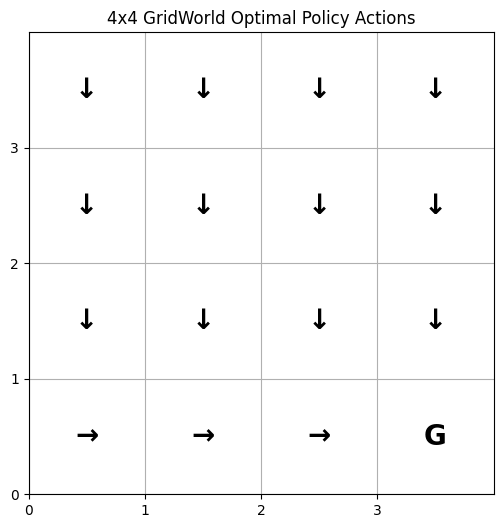

In [2]:
def plot_optimal_policy(policy, grid_size=4):
    fig, ax = plt.subplots(figsize=(6, 6))
    arrow_dict = {'UP': '↑', 'DOWN': '↓', 'LEFT': '←', 'RIGHT': '→', 'GOAL': 'G'}

    for r in range(grid_size):
        for c in range(grid_size):
            action = policy[(r, c)]
            symbol = arrow_dict[action]
            ax.text(c + 0.5, grid_size - r - 0.5, symbol,
                    ha='center', va='center', fontsize=20, weight='bold')

    ax.set_xticks(np.arange(0, grid_size, 1))
    ax.set_yticks(np.arange(0, grid_size, 1))
    ax.grid(True)
    plt.xlim(0, grid_size)
    plt.ylim(0, grid_size)
    plt.title("4x4 GridWorld Optimal Policy Actions")
    plt.show()

plot_optimal_policy(optimal_policy)